# Теория вероятностей и математическая статистика

*Алла Тамбовцева, НИУ ВШЭ*

## Метод главных компонент: практикум с библиотекой `sklearn`

Импортируем необходимые библиотеки и модули:

* стандартный набор: `pandas` для работы с таблицами, `numpy` для работы с массивами, `matplotlib` для графики;
* функция `StandardScaler()` из `sklearn` для стандартизации данных;
* функция `PCA()` из `sklearn` для реализации МГК.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Описание и подготовка данных

Загрузим данные о качестве жизни в крупных городах:

In [2]:
# заодно удалим лишний столбец Unnamed: 0

df = pd.read_csv("https://raw.githubusercontent.com/allatambov/StatCS26/refs/heads/main/city24.csv")
df = df.drop(columns = "Unnamed: 0")
df.head()

,City,Decibel_Level,Traffic_Density,Green_Space_Area,Air_Quality_Index,Happiness_Score,Cost_of_Living_Index,Healthcare_Index
0,New York,70,High,35,40,6.5,100,80
1,Los Angeles,65,Medium,40,50,6.8,90,75
2,Chicago,60,Medium,30,55,7.0,85,70
3,London,55,High,50,60,7.2,110,85
4,Paris,60,High,45,65,6.9,95,80


Пояснения по столбцам:
    
* `city`: название города;
* `Decibel_Level`: уровень шума;
* `Traffic_Density`: плотность трафика, интенсивность дорожного движения;
* `Green_Space_Area`: площадь зеленых насаждений;
* `Air_Quality_Index`: индекс качества воздуха (чем выше, тем грязнее воздух);
* `Happiness_Score`: индекс счастья;
* `Cost_of_Living_Index`: индекс стоимости жизни;
* `Healthcare_Index`: индекс качества здравоохранения.

Запросим размерность датафрейма:

In [3]:
print(df.shape)

(115, 8)


Итак, мы имеем дело с массивом данных из 115 наблюдений – городов. Запросим описательные статистики для числовых столбцов и убедимся, что количественные переменные измерены в разных шкалах (а значит, потребуется стандартизация данных):

In [4]:
# нет пропусков, везде в count указано 115
# везде очень разные максимальные значения, очевидно, что
# это не тот случай, когда мы имеем дело с индексами в единой шкале,
# например, от 1 до 100

df.describe()

,Decibel_Level,Green_Space_Area,Air_Quality_Index,Happiness_Score,Cost_of_Living_Index,Healthcare_Index
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,63.217391,90.391304,76.521739,6.373913,59.695652,80.713043
std,10.906125,80.818586,64.267717,1.702583,31.402082,17.656451
min,50.000000,5.000000,10.000000,2.500000,20.000000,35.000000
25%,55.000000,30.000000,30.000000,5.200000,25.000000,70.000000
50%,60.000000,55.000000,45.000000,6.800000,55.000000,85.000000
75%,70.000000,142.500000,110.000000,7.900000,85.000000,96.000000
max,90.000000,285.000000,245.000000,8.500000,130.000000,99.000000


Выберем числовые столбцы и построим для них корреляционную матрицу:

In [5]:
df.select_dtypes([float, int]).corr()

,Decibel_Level,Green_Space_Area,Air_Quality_Index,Happiness_Score,Cost_of_Living_Index,Healthcare_Index
Decibel_Level,1.000000,-0.652804,0.894348,-0.849789,-0.025931,-0.893477
Green_Space_Area,-0.652804,1.000000,-0.644285,0.386874,-0.574322,0.715619
Air_Quality_Index,0.894348,-0.644285,1.000000,-0.830201,-0.073660,-0.915812
Happiness_Score,-0.849789,0.386874,-0.830201,1.000000,0.222083,0.842902
Cost_of_Living_Index,-0.025931,-0.574322,-0.073660,0.222083,1.000000,0.043111
Healthcare_Index,-0.893477,0.715619,-0.915812,0.842902,0.043111,1.000000


Итак, все представленные показатели скоррелированы друг с другом. Единственное, переменная `Cost_of_Living_Index` слабо скоррелирована с другими переменными, но это объяснимо – стоимость жизни в городе и не должна быть связанной с экологической обстановкой. Есть крупные города, где мало зелени, шумно и нечем дышать, с высокой стоимостью жизни, а есть маленькие зеленые города с благоприятной экологической обстановкой, где все равно жить дорого :) Все сильно зависит от региона.

Для реализации метода главных компонент выберем пять показателей: все переменные из матрицы выше, кроме индекса счастья. Его оставим для проверки валидности нашего интегрального индекса, который мы получим, выбрав первую главную компоненту. Ведь если наш индекс будет отражать уровень благополучия жизни в городе, он должен быть положительно скоррелирован с индексом счастья, поскольку в городах с неблагоприятной обстановкой люди вряд ли ощущают себя счастливыми.

In [6]:
# выбираем столбцы

data = df[["Decibel_Level", "Green_Space_Area", "Air_Quality_Index",
           "Cost_of_Living_Index", "Healthcare_Index"]]
data.head()

,Decibel_Level,Green_Space_Area,Air_Quality_Index,Cost_of_Living_Index,Healthcare_Index
0,70,35,40,100,80
1,65,40,50,90,75
2,60,30,55,85,70
3,55,50,60,110,85
4,60,45,65,95,80


Прошкалируем данные – выполним их стандартизацию (центрирование и нормирование) с помощью `StandardScaler()`:

In [7]:
# fit_transform:
# fit: считает среднее и ст отклонение
# transform: использует их и стандартизирует данные

X = StandardScaler().fit_transform(data)
data_scaled = pd.DataFrame(X, columns = data.columns)
data_scaled.head()

,Decibel_Level,Green_Space_Area,Air_Quality_Index,Cost_of_Living_Index,Healthcare_Index
0,0.624630,-0.688378,-0.570762,1.289110,-0.040561
1,0.164166,-0.626240,-0.414482,0.969266,-0.324983
2,-0.296299,-0.750515,-0.336342,0.809344,-0.609405
3,-0.756763,-0.501965,-0.258202,1.608954,0.243861
4,-0.296299,-0.564102,-0.180062,1.129188,-0.040561


> **Пояснения к коду.** Функция `StandardScaler()` сама по себе просто создает объект класса `StandardScaler`, который существует внутри библиотеки `sklearn`. Этот объект – контейнер, который до того момента как мы применим к нему какие-то методы, почти пуст. По сути мы просто зарезервировали место под результаты центрирования и нормирования данных (представьте, что мы создали пустой список, никаких методов для добавления элементов типа `.append()` еще не применили, но зафиксировали, что именно в этом списке будет храниться). Далее мы применяем к этому контейнеру метод `.fit_transform()`, чтобы наполнить его значениями. В `sklearn` есть три метода – `.fit()`, `.transform()` и `.fit_transform()`. Метод `.fit()` выполняет вычисления на основе данных, поданных на вход. В данном случае он считает среднее и стандартное отклонение по всем столбцам в `data`. Метод `.transform()` преобразует данные на основе предварительно посчитанных в `.fit()` значений. А `.fit_transform()` делает обе эти операции сразу. То есть, мы могли сначала применить `.fit()`, затем – `.transform()`, но мы сделали все одной строчкой. Так как в `sklearn` основной структурой для работы является массив `numpy`, чтобы получить что-то более наглядное, мы превращаем итоговый массив `X` в датафрейм `data_scaled`, забрав названия столбцов из `data`.

Посмотрим на описательные статистики для массива стандартизованных данных:

In [8]:
data_scaled.describe().round(2)

,Decibel_Level,Green_Space_Area,Air_Quality_Index,Cost_of_Living_Index,Healthcare_Index
count,115.00,115.00,115.00,115.00,115.00
mean,-0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00
min,-1.22,-1.06,-1.04,-1.27,-2.60
25%,-0.76,-0.75,-0.73,-1.11,-0.61
50%,-0.30,-0.44,-0.49,-0.15,0.24
75%,0.62,0.65,0.52,0.81,0.87
max,2.47,2.42,2.63,2.25,1.04


Несмотря на то, что мы изменили шкалу, сделав так, что у всех показателей стандартное отклонение 1, разброс значений переменных везде различный – посмотрите на квартили и размах, сравнив минимум и максимум.

Связи в данных после стандартизации тоже не «потерялись»:

In [9]:
data_scaled.corr()

,Decibel_Level,Green_Space_Area,Air_Quality_Index,Cost_of_Living_Index,Healthcare_Index
Decibel_Level,1.000000,-0.652804,0.894348,-0.025931,-0.893477
Green_Space_Area,-0.652804,1.000000,-0.644285,-0.574322,0.715619
Air_Quality_Index,0.894348,-0.644285,1.000000,-0.073660,-0.915812
Cost_of_Living_Index,-0.025931,-0.574322,-0.073660,1.000000,0.043111
Healthcare_Index,-0.893477,0.715619,-0.915812,0.043111,1.000000


Итак, данные готовы, можем приступать к реализации МГК.

## Реализация метода главных компонент

Для удобства (чтобы не гадать, что есть что в результатах) создадим список с названиями главных компонент `PC1`-`PC5`:

In [10]:
# забираем число исходных столбцов = числу главных компонент
# дописываем к PC номера от 1 до 5

p = data_scaled.shape[1]
pca_names = ["PC" + str(i) for i in range(1, p + 1)]
print(pca_names)

['PC1', 'PC2', 'PC3', 'PC4', 'PC5']


Создадим объект класса `PCA`, в котором позже будут храниться результаты реализации метода главных компонент:

In [11]:
# pca – контейнер для хранения результатов PCA
# пока там только информация о числе компонент

pca = PCA(n_components = p)
print(pca)

PCA(n_components=5)


Применим метод `.fit_transform()` к объекту `pca`, чтобы реализовать МГК и:

* получить факторные нагрузки –  веса исходных переменных в главных компонентах;
* получить информативность главных компонент;
* получить значения всех главных компонент для каждого наблюдения – новые координаты точек.

In [12]:
pca_res = pd.DataFrame(pca.fit_transform(data_scaled),
                       columns = pca_names)
pca_res

,PC1,PC2,PC3,PC4,PC5
0,-0.459452,1.401640,0.476790,-0.656195,-0.140122
1,-0.399841,1.102356,-0.024836,-0.419351,-0.290654
2,-0.397080,1.035879,-0.569285,-0.260999,-0.409488
3,0.291234,1.794820,-0.171478,0.380587,-0.243064
4,-0.121525,1.281747,-0.139401,0.073088,-0.180882
...,...,...,...,...,...
110,2.414269,-1.440934,0.468115,0.115904,-0.350111
111,2.012181,-1.750961,0.720978,0.054400,-0.355085
112,2.331505,-1.544082,0.494340,0.257615,-0.470744
113,2.675800,-1.608387,0.162742,0.392363,-0.474905


Мы получили датафрейм со значениями каждой главной компоненты для каждого наблюдения. Первая строка, например, это координаты первого города в новом пространстве из пяти главных компонент. А первый столбец – значения первой главной компоненты для каждого города в данных, то есть значения некоторого интегрального индекса качества жизни для каждого города.

> **Пояснения к коду.** Функция `PCA()`, когда мы подали ей на вход аргумент `n_components = p`, зарезервировала место под результаты реализации метода главных компонент с пятью компонентами. Как и в случае со `StandardScaler()`, далее мы применяем к этому объекту метод `.fit_transform()`. Если бы мы применили просто `.fit()`, Python на основе данных `data_scaled` вычислил бы значения факторных нагрузок (собственные векторы длины 1 ковариационной матрицы для `data_scaled`) и информативность главных компонент (собственные числа ковариационной матрицы для `data_scaled`). Если бы мы после этого применили `.transform()`, Python бы использовал факторные нагрузки как веса исходных переменных и пересчитал координаты точек в новой системе. А раз мы применяем `.fit_transform()` Python выполняет обе операции сразу, и поэтому в `pca_res` у нас хранятся координаты точек в новой системе – значения главных компонент для каждого города (снова для наглядности переделали массив в датафрейм), а из `pca` мы позже сможем извлечь факторные нагрузки и информативность главных компонент для интерпретации полученных результатов.

**NB.** В `sklearn` разных версий результаты могут отличаться. Мы обсуждали, что нет единственного решения при получении собственных векторов ковариационной матрицы, даже если мы добавим ограничение на длину векторов. Из-за этого веса исходных показателей в главных компонентах могут быть другими, а значит, и значения главных компонент тоже. Поскольку расхождения возникают только из-за знаков, различия будут только в интерпретации главных компонент.

Убедимся, что полученные главные компоненты не скоррелированы:

In [13]:
print(pca_res.corr().round())

     PC1  PC2  PC3  PC4  PC5
PC1  1.0 -0.0 -0.0  0.0 -0.0
PC2 -0.0  1.0 -0.0 -0.0  0.0
PC3 -0.0 -0.0  1.0 -0.0  0.0
PC4  0.0 -0.0 -0.0  1.0 -0.0
PC5 -0.0  0.0  0.0 -0.0  1.0


## Выбор числа главных компонент

Посмотрим на **информативность главных компонент**. Выведем дисперсии главных компонент – собственные значения ковариационной матрицы:

In [14]:
# атрибут .explained_variance_,
# забираем из pca

pca_var = pca.explained_variance_
print(pca_var.round(2))

[3.42 1.34 0.14 0.1  0.05]


Итак, дисперсия первой главной компоненты 3.42, второй – 1.34, третьей 0.14, далее дисперсии совсем маленькие. По **правилу Кайзера** следует извлечь две главные компоненты, так как только два собственных значения (две дисперсии) больше 1. Значения, которые мы получили в массиве выше – это главная диагональ матрицы $S$, которую мы рассматривали на лекции.

Визуализуем результаты – построим **график каменистой осыпи**, он же график согнутого локтя, он же график согнутого колена, он же график сломанной трости и **scree plot**:

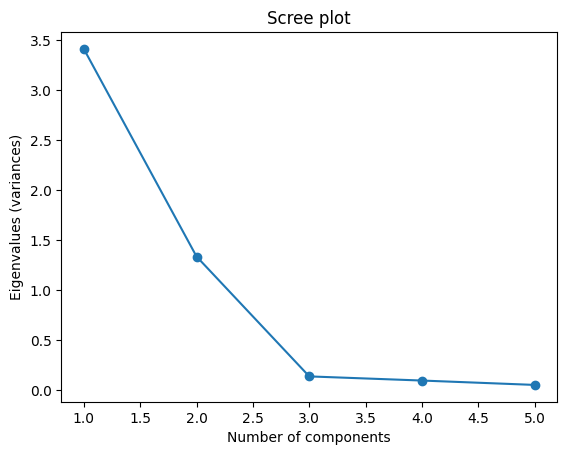

In [15]:
# по оси x – число компонент от 1 до 5
# по оси y – собственные значения (дисперсии)
# o- дает точки, соединенные линией

plt.plot(range(1, p + 1), pca_var, "o-");
plt.title("Scree plot");
plt.xlabel("Number of components");
plt.ylabel("Eigenvalues (variances)");

Как и все графические способы, этот метод определения числа главных компонент не совсем однозначный. Обычно считается, что нужно извлечь столько главных компонент, сколько находятся до излома (колена/локтя) на графике. Здесь излом происходит на трех главных компонентах, формально до него две главные компоненты, включать ли третью или нет – уже на усмотрение исследователя. Можно согласовать результаты с другими методами определения числа главных компонент.

Вычислим доли дисперсии исходных данных, которые объясняет каждая главная компонента (переведём в проценты и округлим):

In [16]:
# вместо .explained_variance вызываем
# explained_variance_ratio_

pca_var_ratio = pca.explained_variance_ratio_
print((pca_var_ratio * 100).round(2))

[67.72 26.53  2.75  1.93  1.06]


Первая главная компонента объясняет 67.72% дисперсии исходных данных, вторая – 26.53% дисперсии исходных данных. В сумме эти две главные компоненты объясняют примерно 94% дисперсии, этого достаточно (более 85-90% на практике). Чтобы не считать совокупные проценты объясненной дисперсии самостоятельно, можно воспользоваться функцией `cumsum()` для массивов:

In [17]:
print(np.cumsum((pca_var_ratio * 100).round(2)))

[67.72 94.25 97.   98.93 99.99]


Теперь точно видно, что две первые главные компоненты объясняют 94.25% дисперсии исходных данных, три компоненты – уже 98.93%, все компоненты объясняют 100%, просто из-за накопленной ошибки иногда получается 99.9(9)%.

## Интерпретация главных компонент

Выведем нагрузки – веса, те значения, которые являются координатами единичных собственных векторов ковариационной матрицы:

In [18]:
# строка = единичный собственный вектор
# для одной компоненты

print(pca.components_)

[[-0.50879432  0.45178824 -0.51002823 -0.07806969  0.52037685]
 [-0.16094092 -0.43768898 -0.19995386  0.84786247  0.15386379]
 [ 0.70753637  0.48111069  0.07189299  0.32815967  0.39378599]
 [-0.44937478  0.26486289  0.81074544  0.21406351  0.15741219]
 [ 0.1126097  -0.55017806  0.19342413 -0.34860062  0.72504336]]


На лекции мы записывали нагрузки по столбцам, поэтому транспонируем таблицу выше, для наглядности преобразуем в датафрейм и закрепим за строками и столбцами понятные названия:

In [19]:
# приведем в привычный вид
# подумаем над интерпретацией

P = pd.DataFrame(pca.components_).T
P.columns = pca_names
P.index = data.columns
P

,PC1,PC2,PC3,PC4,PC5
Decibel_Level,-0.508794,-0.160941,0.707536,-0.449375,0.112610
Green_Space_Area,0.451788,-0.437689,0.481111,0.264863,-0.550178
Air_Quality_Index,-0.510028,-0.199954,0.071893,0.810745,0.193424
Cost_of_Living_Index,-0.078070,0.847862,0.328160,0.214064,-0.348601
Healthcare_Index,0.520377,0.153864,0.393786,0.157412,0.725043


Итак, `P` – это матрица поворота, она же матрица перехода, которую мы рассматривали на занятии. Проверим, что для нее выполняются необходимые свойства:

In [20]:
# p – ортогональная матрица
# сумма квадратов элементов по столбцам (axis = 0) равна 1
# сумма квадратов элементов по строкам (axis = 1) равна 1
# при умножении саму на себя дает единичную матрицу

print((P ** 2).sum(axis = 0)) # 1
print((P ** 2).sum(axis = 1)) # 1
print(P.dot(P.T).round(2)) # I

PC1    1.0
PC2    1.0
PC3    1.0
PC4    1.0
PC5    1.0
dtype: float64
Decibel_Level           1.0
Green_Space_Area        1.0
Air_Quality_Index       1.0
Cost_of_Living_Index    1.0
Healthcare_Index        1.0
dtype: float64
                      Decibel_Level  Green_Space_Area  Air_Quality_Index  \
Decibel_Level                   1.0              -0.0               -0.0   
Green_Space_Area               -0.0               1.0               -0.0   
Air_Quality_Index              -0.0              -0.0                1.0   
Cost_of_Living_Index           -0.0               0.0                0.0   
Healthcare_Index                0.0               0.0               -0.0   

                      Cost_of_Living_Index  Healthcare_Index  
Decibel_Level                         -0.0               0.0  
Green_Space_Area                       0.0               0.0  
Air_Quality_Index                      0.0              -0.0  
Cost_of_Living_Index                   1.0               0.0  
Hea

Теперь перейдем к интерпретации. Выведем еще раз матрицу факторных нагрузок:

In [21]:
print(P)

                           PC1       PC2       PC3       PC4       PC5
Decibel_Level        -0.508794 -0.160941  0.707536 -0.449375  0.112610
Green_Space_Area      0.451788 -0.437689  0.481111  0.264863 -0.550178
Air_Quality_Index    -0.510028 -0.199954  0.071893  0.810745  0.193424
Cost_of_Living_Index -0.078070  0.847862  0.328160  0.214064 -0.348601
Healthcare_Index      0.520377  0.153864  0.393786  0.157412  0.725043


Мы уже выяснили, что следует извлечь две главные компоненты, поэтому сфокусируемся на столбцах `PC1` и `PC2`. Из матрицы нагузок получаем (веса округлены):

`PC1`= –0.51 `Decibel_Level` + 0.45 `Green_Space` – 0.51 `Air_Quality` – 0.08 `Cost_of_Living` + 0.52 `Health_Index`

`PC2`= -0.16 `Decibel_Level` - 0.44 `Green_Space` – 0.20 `Air_Quality` + 0.85 `Cost_of_Living` + 0.15 `Health_Index`

Используя эти уравнения и исходные данные, мы сможем для любого города вычислить значение $\text{PC}_1$ и $\text{PC}_2$ как некоторых интегральных индекса, подставив вместо переменных конкретные числа – **стандартизованные значения исходных переменных**. Что это за индексы?

С наибольшими положительными весами в первую главную компоненту входят показатели *площадь зеленых насаждений* и *индекс качества здравоохранения*, с наибольшими отрицательными – *уровень шума* и *уровень загрязненности воздуха*. Получается, первая главная компонента отвечает за экологическое благополучие (или вообще благополучие) жизни в городе.

Во второй главной компоненте главную роль играет показатель *стоимость жизни*. Если для дальнейшей работы с данными первого индекса экологического благополучия будет недостаточно, мы можем уравновесить его еще одим индексом, который больше всего «дублирует» исходный столбец `Cost_of_Living_Index`, отвечающий за материальный аспект проживания в городе.

## Интерпретация главных компонент: статистические аспекты

Матрицу `P` выше в классическом факторном анализе обычно называют матрицей **стандартизованных** факторных нагрузок, поскольку она получается приведением собственных векторов ковариационной матрицы к длине 1 (сумма квадратов элементов и по строкам, и по столбцам равна 1). Для задачи получения интегральных индексов этой матрицы достаточно – достаточно удобно оперировать весами, на которые наложены некоторые ограничения. Однако если рассмотреть матрицу нестандартизованных факторных нагрузок, можно получить больше возможностей для интерпретации полученных весов с точки зрения статистики.

Домножим матрицу `P` выше на квадратные корни из собственных значений:

In [22]:
A = P * np.sqrt(pca_var)
A

,PC1,PC2,PC3,PC4,PC5
Decibel_Level,-0.940337,-0.186180,0.263683,-0.140239,0.026077
Green_Space_Area,0.834980,-0.506328,0.179299,0.082657,-0.127405
Air_Quality_Index,-0.942617,-0.231311,0.026793,0.253014,0.044791
Cost_of_Living_Index,-0.144286,0.980825,0.122298,0.066804,-0.080726
Healthcare_Index,0.961743,0.177993,0.146755,0.049124,0.167899


Мы перешли к матрице из собственных векторов, чья длина равна не 1, а корню из собственного значения:

In [23]:
# A – не ортогональная матрица, но вектор-столбцы в ней орготональны
# сумма квадратов элементов по столбцам (axis = 0) равна lambda
# сумма квадратов элементов по строкам (axis = 1) равна 1
# при умножении саму на себя дает единичную матрицу

print((A ** 2).sum(axis = 0)) # lambda
print((A ** 2).sum(axis = 1)) # 1
print("Для сравнения λ:", pca_var)

PC1    3.415720
PC2    1.338234
PC3    0.138889
PC4    0.097391
PC5    0.053625
dtype: float64
Decibel_Level           1.008772
Green_Space_Area        1.008772
Air_Quality_Index       1.008772
Cost_of_Living_Index    1.008772
Healthcare_Index        1.008772
dtype: float64
Для сравнения λ: [3.41572033 1.33823401 0.13888897 0.09739103 0.05362531]


Квадраты нагрузок в такой матрице показывают доли дисперсий каждого исходного показателя, объясненных компонентами:

In [24]:
A ** 2

,PC1,PC2,PC3,PC4,PC5
Decibel_Level,0.884233,0.034663,0.069529,0.019667,0.000680
Green_Space_Area,0.697192,0.256368,0.032148,0.006832,0.016232
Air_Quality_Index,0.888527,0.053505,0.000718,0.064016,0.002006
Cost_of_Living_Index,0.020818,0.962017,0.014957,0.004463,0.006517
Healthcare_Index,0.924950,0.031681,0.021537,0.002413,0.028190


Так, первая главная компонента объясняет 88% дисперсии признака `Decibel_Level`, 69% дисперсии признака `Green_Space_Area`, 89% дисперсии признака `Air_Quality_Index`, и так далее. Все главные компоненты объясняют 100% дисперсии каждого признака, поэтому по строкам сумма элементов такой матрицы равна 1.

Если умножить матрицу `A` саму на себя, мы получим ковариационную матрицу исходных данных:

In [25]:
# A * A^T = Sigma, восстанавливаем ковариационную матрицу

print(pd.DataFrame(np.dot(A, A.T).round(2)))
print("Covariance (unbiased covariance): \n", data_scaled.cov().round(2))

      0     1     2     3     4
0  1.01 -0.66  0.90 -0.03 -0.90
1 -0.66  1.01 -0.65 -0.58  0.72
2  0.90 -0.65  1.01 -0.07 -0.92
3 -0.03 -0.58 -0.07  1.01  0.04
4 -0.90  0.72 -0.92  0.04  1.01
Covariance (unbiased covariance): 
                       Decibel_Level  Green_Space_Area  Air_Quality_Index  \
Decibel_Level                  1.01             -0.66               0.90   
Green_Space_Area              -0.66              1.01              -0.65   
Air_Quality_Index              0.90             -0.65               1.01   
Cost_of_Living_Index          -0.03             -0.58              -0.07   
Healthcare_Index              -0.90              0.72              -0.92   

                      Cost_of_Living_Index  Healthcare_Index  
Decibel_Level                        -0.03             -0.90  
Green_Space_Area                     -0.58              0.72  
Air_Quality_Index                    -0.07             -0.92  
Cost_of_Living_Index                  1.01              0.04  


Более того, раз данные у нас нормированы (мы приводили все к виду, где стандартное отклонение 1), ковариационная и корреляционная матрица совпадают. Однако из-за того, что выше считается несмещенная оценка ковариации, на диагонали мы видим не 1, а близкие к тому значения.

И немного магии: если мы выберем две строки из матрицы `A` и вычислим их скалярное произведение, мы получим ковариацию между соответствующими переменными в исходных данных:

In [26]:
i = A.loc["Decibel_Level", :]
j = A.loc["Air_Quality_Index", :]
print("Скалярное произведение:", np.dot(i, j).round(3))
print("Корреляция:", data_scaled.cov().loc["Decibel_Level",
                                  "Air_Quality_Index"].round(3))

Скалярное произведение: 0.902
Корреляция: 0.902


## Оцениваем результаты и работаем в пространстве сниженной размерности

Добавим в исходный датафрейм `df` с нестандартизованными данными индексы, которые мы получили из первых двух главных компонент:

In [27]:
df["Index1"] = pca_res["PC1"]
df["Index2"] = pca_res["PC2"]

Выведем описательные статистики по ним:

In [28]:
df[["Index1", "Index2"]].describe().round(2)

,Index1,Index2
count,115.00,115.00
mean,-0.00,-0.00
std,1.85,1.16
min,-3.90,-1.75
25%,-1.42,-1.10
50%,0.31,-0.05
75%,1.62,1.04
max,2.68,2.17


Так как при получении значений главных компонент мы использовали стандартизованный набор данных и веса с ограничением на их сумму (сумма квадратов весов равна 1), здесь мы получили набор значений в диапазоне примерно от $-3$ до $3$ (но выбросы никто не отменял).

Отсортируем строки по убыванию значения первого индекса:

In [29]:
df.sort_values("Index1", ascending = False)

,City,Decibel_Level,Traffic_Density,Green_Space_Area,Air_Quality_Index,Happiness_Score,Cost_of_Living_Index,Healthcare_Index,Index1,Index2
113,Whangarei,50,Low,280,25,4.8,20,97,2.675800,-1.608387
109,Mangawhai,50,Low,260,25,5.8,20,97,2.563508,-1.499599
114,Dargaville,55,Low,285,20,4.5,25,98,2.526562,-1.549722
105,Warkworth,50,Low,240,25,6.8,20,97,2.451216,-1.390811
110,Te Hana,55,Low,265,20,5.5,25,98,2.414269,-1.440934
...,...,...,...,...,...,...,...,...,...,...
65,Phnom Penh,80,Very High,10,225,2.5,30,35,-3.700233,-1.480839
64,Hanoi,85,Very High,15,220,3.0,35,40,-3.731067,-1.387165
69,Jakarta,85,Very High,10,245,3.0,35,45,-3.810401,-1.394327
59,Dhaka,90,Very High,5,195,2.5,35,40,-3.822226,-1.328756


Итак, в топе города Whangarei, Mangawhai, Dargaville – города в Новой Зеландии, гдн низкий уровень шума, низкая транспортная загруженность, огромные площади зеленых насаждений и чистый воздух, плюс, высокое качество здравоохранения. В низу рейтинга – города Hanoi, Jakarta, Dhaka	 и Ho Chi Minh City – шумные азиатские города с высокой транспортной загруженностью, малым количеством зелени и невысоким качеством здравоохранения. Значения индекса экологического благополучия города получились логичными, и мы можем на его основе решать, какие города более благополучны, какие – менее.

Проделаем то же самое для второго индекса:

In [30]:
df.sort_values("Index2", ascending = False)

,City,Decibel_Level,Traffic_Density,Green_Space_Area,Air_Quality_Index,Happiness_Score,Cost_of_Living_Index,Healthcare_Index,Index1,Index2
20,Singapore,65,High,45,60,7.0,125,95,0.053156,2.168102
22,Hong Kong,75,High,25,100,5.5,130,90,-1.007020,2.095509
33,Oslo,50,Low,85,25,8.5,115,99,1.402936,2.046045
6,Tokyo,65,High,30,70,6.0,120,90,-0.246292,2.039090
9,Sydney,55,Low,60,30,7.8,115,88,0.662821,1.996021
...,...,...,...,...,...,...,...,...,...,...
112,Ruakaka,55,Low,275,30,5.0,25,96,2.331505,-1.544082
114,Dargaville,55,Low,285,20,4.5,25,98,2.526562,-1.549722
113,Whangarei,50,Low,280,25,4.8,20,97,2.675800,-1.608387
107,Leigh,60,Medium,250,35,6.2,20,95,1.899889,-1.642173


В топе города с высокой стоимостью жизни, в низу рейтинга – города с низкой стоимостью жизни. Полученный индекс, действительно, отражает только один ключевой аспект, нельзя сказать, что города в верху и в низу рейтинга принципиально отличаются по другим параметрам: и там, и там, встречаются города с примерно одинаковыми значениями уровня шума, загрязненности воздуха и качеством здравоохранения.

Проверим, что корреляция между индексами равна 0, а также посмотрим на корреляцию первого основного индекса с уровнем счастья:

In [31]:
df[["Index1", "Index2", "Happiness_Score"]].corr().round(2)

,Index1,Index2,Happiness_Score
Index1,1.00,-0.00,0.79
Index2,-0.00,1.00,0.39
Happiness_Score,0.79,0.39,1.00


Корреляция между первым индексом и уровнем счастья достаточно высокая и положительная, можем считать, что наш индекс, по крайней мере, отражает благоприятные аспекты жизни в городе.

**NB.** Если построение индекса является ключевой задачей исследования (не просто «схлопнуть» показатели в один для модели или для борьбы с мультиколлинерностью, а как предложить методологию измерения), стоит более аккуратно проверять его валидность (конструктивную валидность). В данном случае хорошо было бы найти иные индексы благополучия жизни в городе или рейтинги, чтобы оценить связь с ними.

Построим диаграмму рассеивания для полученных индексов:

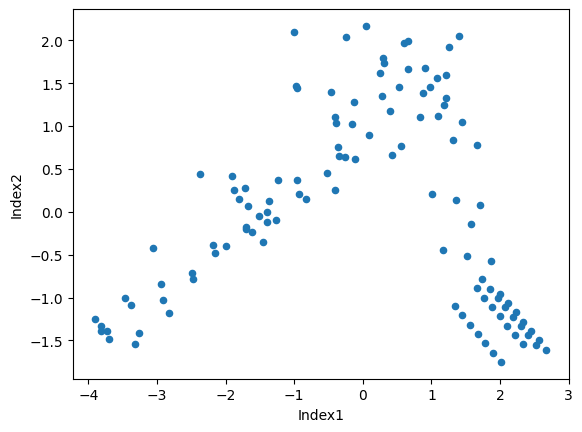

In [32]:
df.plot.scatter(x = "Index1", y = "Index2");

Мы перешли из исходного пространства, где у нас было пять переменных (пять осей), к двумерному пространству (две оси), то есть мы спроецировали все точки на плоскость, которая «натянута» на собственные вектора ковариационной матрицы. В таком виде данные удобно визуализировать и интерпретировать.

## Визуализируем результаты (дополнительно)

Установим библиотеку `pca` (надстройка над `PCA()` из `sklearn`, просто с доработанными функциями для визуализации):

In [35]:
#!pip install pca

Импортируем функцию `pca()` из установленной библиотеки:

In [36]:
from pca import pca

Создадим объект класса `pca` из библиотеки `pca`:

In [37]:
# сразу включаем стандартизацию
# StandardScaler() запустится сам

pc = pca(normalize = True)

Запустим реализацию метода главных компонент по аналогии с тем, что было ранее (тот же метод, но в этой библиотеке его результаты можно использовать для визуализации):

In [38]:
# col_labels - названия исходных столбцов из data
# чтобы было понятно в результатах, что где

res = pc.fit_transform(data, col_labels = data.columns)

[10-06-2026 08:51:23] [pca.pca] [INFO] Extracting row labels from dataframe.
[10-06-2026 08:51:23] [pca.pca] [INFO] Normalizing input data per feature (zero mean and unit variance)..
[10-06-2026 08:51:23] [pca.pca] [INFO] PCA reduction performed to capture at least 95.0% explained variance using 5 columns of the input data.
[10-06-2026 08:51:23] [pca.pca] [INFO] Fit using PCA.
[10-06-2026 08:51:23] [pca.pca] [INFO] Compute loadings and PCs.
[10-06-2026 08:51:23] [pca.pca] [INFO] Compute explained variance.
[10-06-2026 08:51:23] [pca.pca] [INFO] The top 3 principal component(s) explains >= 95.00% of the explained variance.
[10-06-2026 08:51:23] [pca.pca] [INFO] The PCA reduction is performed on 5 variables (columns) of the input dataframe.
[10-06-2026 08:51:23] [pca.pca] [INFO] Fit using PCA.
[10-06-2026 08:51:23] [pca.pca] [INFO] Compute loadings and PCs.
[10-06-2026 08:51:23] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[3]
[10-06-2026 

Почему в перечне выполняемых действий выше фигурируют только три главных компоненты, хотя в `data` было пять столбцов? Алгоритм по умолчанию работает так: реализует метод главных компонент на всех столбцах, а затем отбирает в результаты столько главных компонент, сколько в сумме объясняют не менее 95% дисперсии исходных данных:

    Number of components is [3] that covers the [95.00%] explained variance.
    
Если мы посмотрим, что находится внутри `res`, мы обнаружим там большой словарь со следующими ключами и значениями:

* `loadings`: нагрузки, веса исходных показателей в главных компонентах;
* `PC`: значения главных компонент для каждого наблюдения (датафрейм);
* `explained_var`: совокупная доля дисперсии, объясненной первыми $k$ главными компонентами;
* `variance_ratio`: доля дисперсии, объясненной каждой компонентой;
* `model`: описание параметров алгоритма;
* `topfeat`:  показатели с самыми большими весами по модуля (и в какие компоненты они входят);
* `outliers`: характеристики, позволяющие понять, являются ли наблюдения выбросами (датафрейм);
* `outliers_params`: наблюдения, считающиеся выбросами, и их характеристики.

In [ ]:
# можно раскомментировать и посмотреть
# res

Построим график для информативности главных компонент:

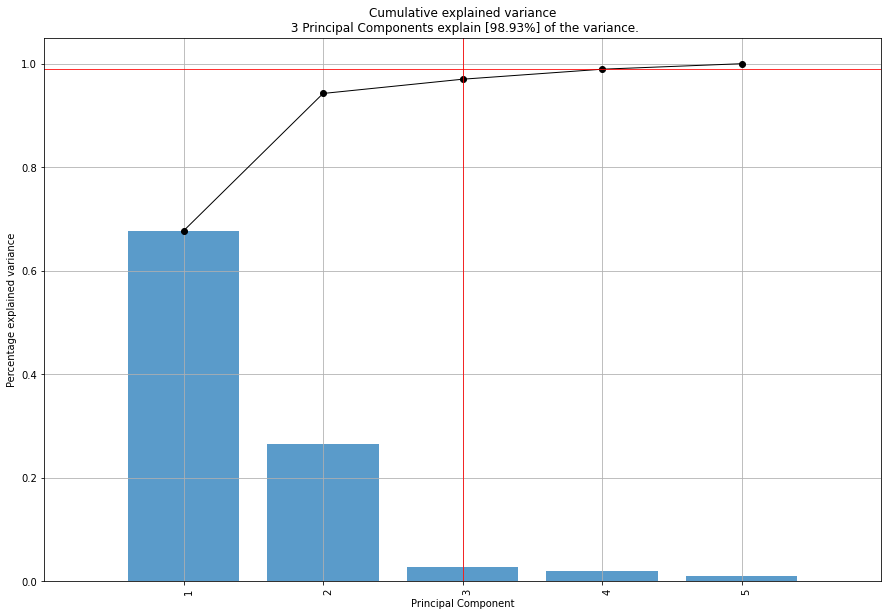

In [ ]:
pc.plot();

График выше – доработанный график каменистой осыпи (правда, вместо осыпи здесь теперь «насыпь»). По горизонтальной оси по-прежнему число главных компонент, по вертикальной – их их информативность, доля объясненной дисперсии. Только линией теперь соединены не точки, соответствующие информативности каждой главной компоненты, а точки, соответствующие их **совокупной информативности**. Но логика та же, можем выбрать столько главных компонент, сколько до «излома» графика, то есть две.

Построим график *biplot*, который позволяет посмотреть на соотношение исходных показателей и главных компонент:

[10-06-2026 08:51:29] [pca.pca] [INFO] Plot PC1 vs PC2 with loadings.
[10-06-2026 08:51:29] [scatterd.scatterd] [INFO] Create scatterplot


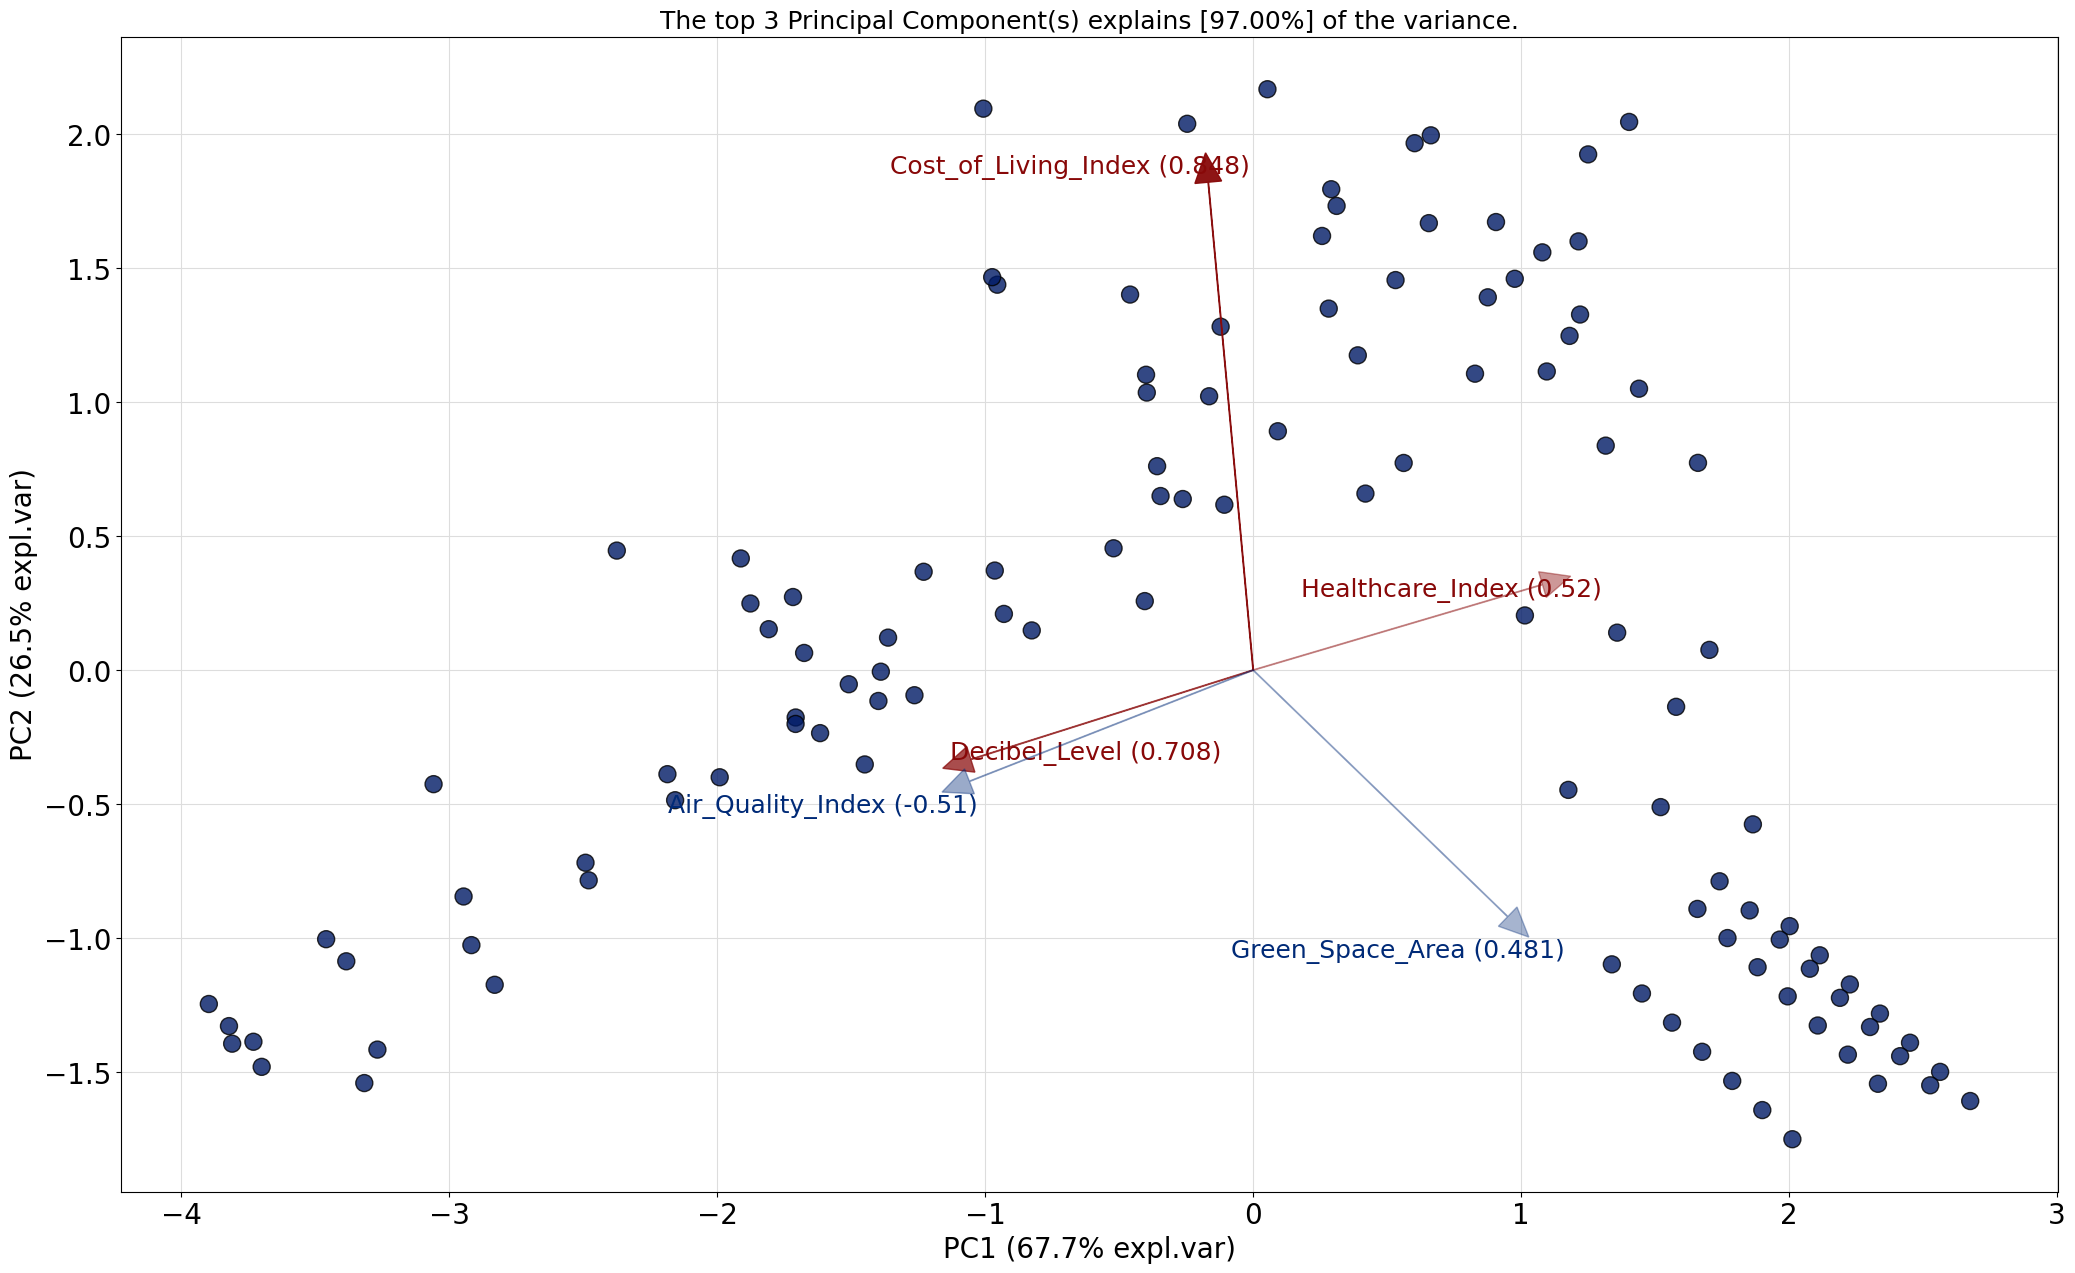

In [39]:
pc.biplot();

Этот график отображает то, что мы только что увидели в перечне нагрузок. Какие-то исходные показатели (вектора) сонаправлены с первой главной компонентой по горизонтальной оси (положительно связаны с ней, это все те же `Green_Space_Area` и `Healthcare_Index`), какие-то – направлены в противоположную сторону (отрицательно связаны с ней, это все те же `Decibel_Level`, `Air_Quality_Index`, `Cost_of_Living_Index`).

Однако этот график обычно используют без точек, достаточно векторов. Чтобы точки не мешали, выключим их:

[10-06-2026 08:51:35] [pca.pca] [INFO] Plot PC1 vs PC2 with loadings.
[10-06-2026 08:51:35] [scatterd.scatterd] [INFO] Create scatterplot


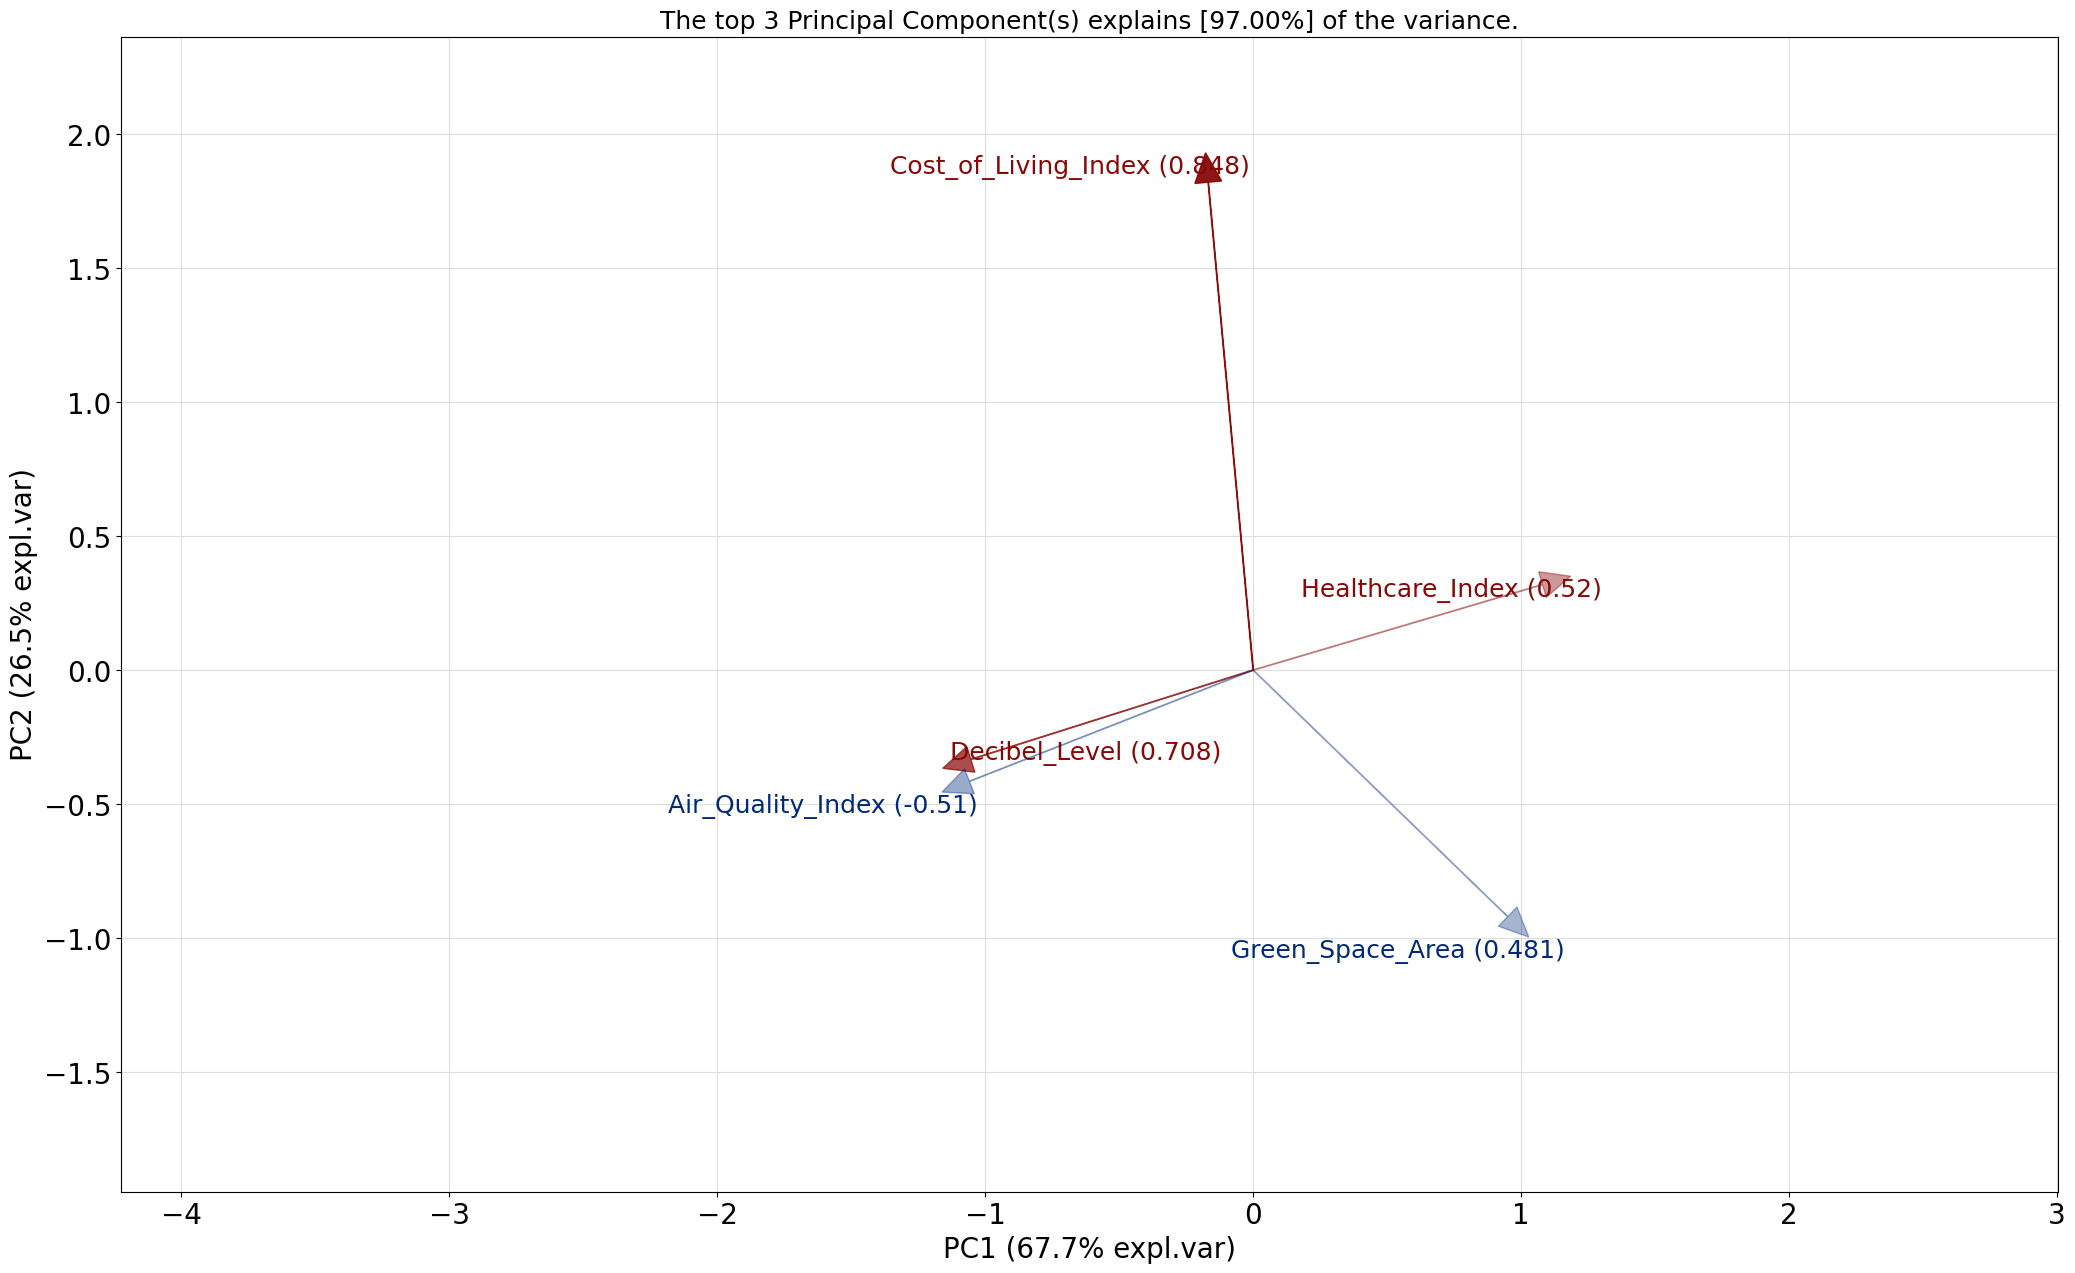

In [40]:
pc.biplot(cmap = None);

А если точки важны, можем, наоборот, еще совместную плотность на график добавить:

[10-06-2026 08:51:38] [pca.pca] [INFO] Plot PC1 vs PC2 with loadings.
[10-06-2026 08:51:38] [scatterd.scatterd] [INFO] Add density layer
[10-06-2026 08:51:38] [scatterd.scatterd] [INFO] Create scatterplot


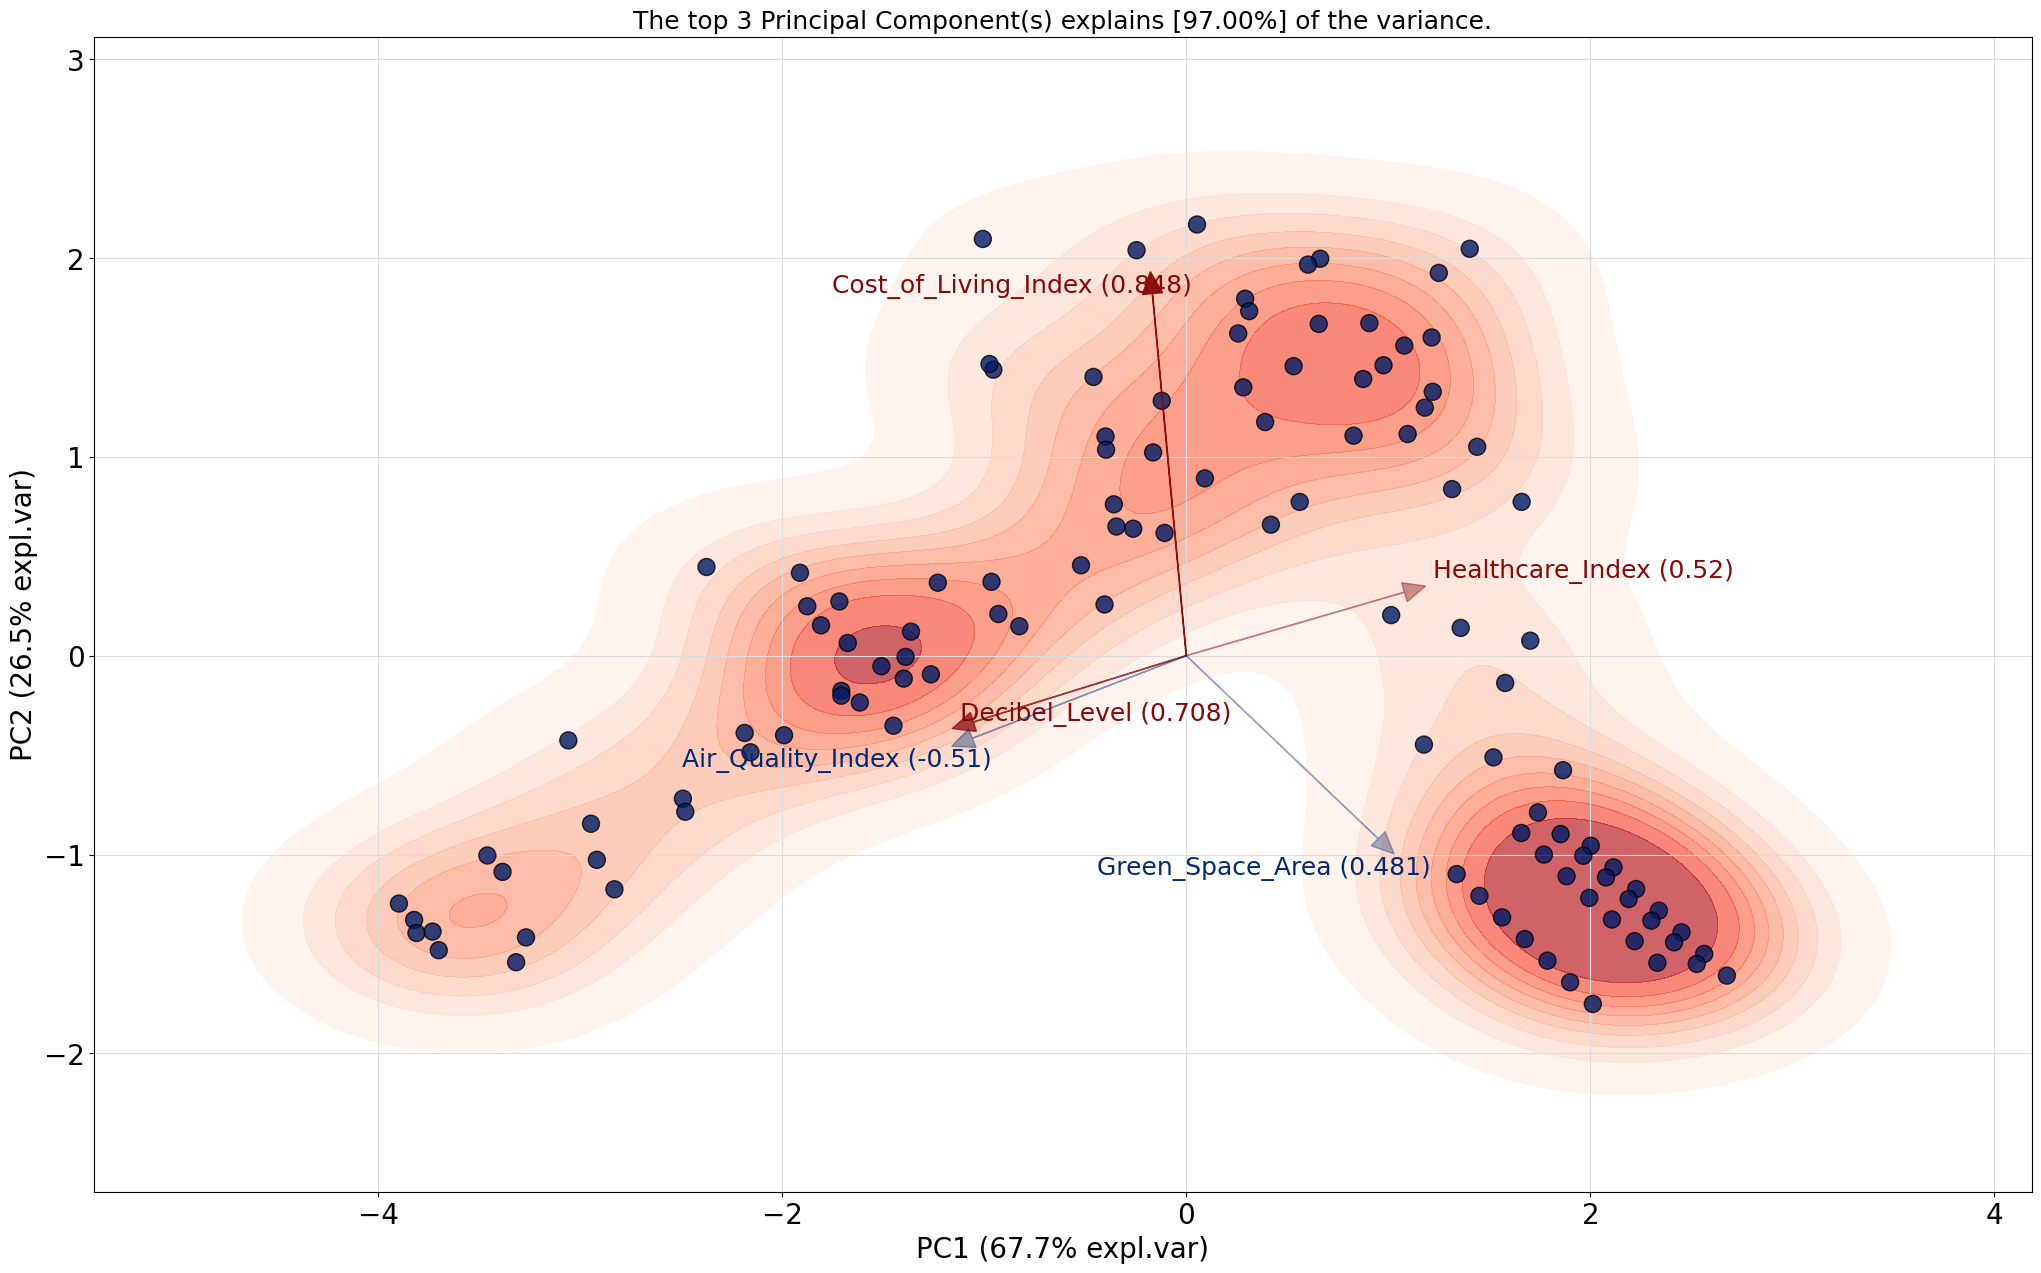

In [41]:
pc.biplot(density = True);

Так как график совместной плотности `PC1` и `PC2` на плоскости просто так не отображается (это функция от двух переменных), здесь она представлена линиями уровня и цветом (как на физической географической карте). Где цвет более темный – там больше всего точек, значения совместной плотности `PC1` и `PC2` высокие, где цвет более светлый – там точек мало, значения совместной плотности `PC1` и `PC2` низкие. По сути, если не обращать внимание на вектора, которые мы уже обсудили, это – доработанная диаграмма рассеивания, по которой можно проследить наличие групп в совместном распределении показателей.

Пояснения для понимания:

   * Вспомните, что плотность нормального распределения в одномерном случае – это колокообразная функция на плоскости. В двумерном случае совместная плотность двух нормальных случайных величин – это колокообразных «холм» определенной высоты (советую эту интерактивную [симуляцию](https://socr.umich.edu/HTML5/BivariateNormal/)). Если у двух независимых нормальных случайных величин одинаковые средние и дисперсии, это «холм» с круглым основанием, если у первой величины дисперсия больше, основание «холма» вытянуто вдоль первой оси сильнее, основание у «холма» овальное. Если величины не независимые, то основание «холма» еще имеет наклон. На графике выше связь между `PC1` и `PC2` (теоретически они нескоррелированы, но на конкретной выборке коэффициент Пирсона не 0) на участке в окрестности $PC1 = -2$ положительная, основание «холма» имеет положительный наклон, в окрестности $PC1 = 4$ – отрицательная, основание «холма» имеет отрицательный наклон.

* Отсюда самые темные области на графике – это пики «холмов», то есть пики совместных плотностей. Каждый пик – это своего рода центр тяжести каждой группы точек, центр тяжести каждого кластера. Здесь есть явная группа наблюдений, сконцентрированная вокруг пика в точке в окрестности (-2; -1), и расплывчатая группа наблюдений с тремя пиками внутри. Между этой маленькой группой и расплывчатой большой есть большой зазор - относительно большое расстояние между «подножиями холмов», группы разные. Большую расплывчатую группу, в целом, тоже можно поделить на подгруппы, как раз по трем пикам.

* В целом, если совместное распределение можно считать нормальным, для разделения данных на группы, помимо кластерного анализа, где распределение не так важно, можно использовать расщепление смесей (*mixture models*), в нем как раз реализуется идея проведения границ на основе значений функций совместной плотности.